# 01 - Generate Perturbations

This notebook generates RRPR perturbations using a weighted ensemble of
AdaFace, ArcFace, and MagFace.

Generated perturbations:

- PGD
- DCT-HF
- DWT-HF
- BPDA-EOT

Inputs:

- Dataset/
- models/
- repos/

Outputs:

- image-output/

Expected Runtime:

- Demo Mode: 1-2 hours
- Full Dataset: 1-2 days

GPU Required:

- Yes

In [1]:
try:
    from google.colab import drive

    drive.mount("/content/drive")

    print("Google Drive mounted.")

except ImportError:

    print("Running outside Colab. Drive mount skipped.")

Mounted at /content/drive


In [ ]:
!pip install -q torch-dct
!pip install -q PyWavelets
!pip install -q tqdm
!pip install -q opencv-python
!pip install -q scikit-learn
!pip install -q pandas
!pip install -q pillow

## Configuration

This section defines:

- Dataset selection
- Demo mode configuration
- Output directories
- Random seed
- Perturbation parameters

In [2]:
from pathlib import Path
import os
import sys
import random
import logging
import shutil
from collections import defaultdict
import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms

# Seed
RANDOM_SEED = 0
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

# Demo mode True for inference on subset and Demo mode False for final total generation on full dataset
DEMO_MODE = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [3]:
# Update paths accordingly

PROJECT_ROOT = Path("/content/drive/MyDrive/Free-Cloud/ICPR_Rep")
DATASET_ROOT = PROJECT_ROOT / "Dataset"
OUTPUT_ROOT = PROJECT_ROOT / "image-output"
MODELS_DIR = PROJECT_ROOT / "models"
REPOS_DIR = PROJECT_ROOT / "repos"
METADATA_DIR = OUTPUT_ROOT / "metadata"

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)

print(PROJECT_ROOT)

/content/drive/MyDrive/Free-Cloud/ICPR_Rep


In [ ]:
log_file_path = OUTPUT_ROOT / "perturbation_generation.log"
root_logger = logging.getLogger()

if root_logger.hasHandlers(): root_logger.handlers.clear()

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] - %(message)s",
    handlers=[logging.FileHandler(log_file_path, mode="w"), logging.StreamHandler()]
)

logger = logging.getLogger()
logger.info("Notebook 01 Started")

2026-06-10 12:21:11,241 [INFO] - Notebook 01 Started


In [ ]:
DATASETS = [
    "FERET",
    "FRGC"
]

ATTACK_FOLDER_MAP = {

    "PGD":
    "Weighted_Ensemble_Template_PGD",

    "DCT_HF":
    "Weighted_Ensemble_Template_DCT_HF",

    "DWT_HF":
    "Weighted_Ensemble_Template_DWT_HF",

    "BPDA_EOT":
    "Weighted_Ensemble_Template_BPDA_EOT"
}

In [ ]:
# Output structure
for dataset in DATASETS:
    dataset_root = OUTPUT_ROOT / dataset

    # Original
    (dataset_root / "original" / "aligned" / "train").mkdir(parents=True, exist_ok=True)
    (dataset_root / "original" / "aligned" / "test").mkdir(parents=True, exist_ok=True)

    # Perturbed
    for attack_folder in ATTACK_FOLDER_MAP.values():
        (dataset_root / attack_folder / "aligned" / "train").mkdir(parents=True, exist_ok=True)
        (dataset_root / attack_folder / "aligned" / "test").mkdir(parents=True, exist_ok=True)

print("Output structure ready.")

Output structure ready.


In [ ]:
ADAFACE_REPO = REPOS_DIR / "AdaFace"
MAGFACE_REPO = REPOS_DIR / "MagFace"
ELASTICFACE_REPO = REPOS_DIR / "ElasticFace"
EDGEFACE_REPO = REPOS_DIR / "edgeface"

print(ADAFACE_REPO.exists())
print(MAGFACE_REPO.exists())
print(ELASTICFACE_REPO.exists())
print(EDGEFACE_REPO.exists())

True
True
True
True


In [ ]:
# Assumin all the required checkpoints are there in the {Working Directory}/models

In [ ]:
# ArcFace Architecture

def conv3x3(in_planes, out_planes, stride=1, groups=1, dilation=1):
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride, padding=dilation, groups=groups, bias=False, dilation=dilation)


def conv1x1(in_planes, out_planes, stride=1):
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)


class IBasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(inplanes, eps=1e-5)
        self.conv1 = conv3x3(inplanes, planes)
        self.bn2 = nn.BatchNorm2d(planes, eps=1e-5)
        self.prelu = nn.PReLU(planes)
        self.conv2 = conv3x3(planes, planes, stride)
        self.bn3 = nn.BatchNorm2d(planes, eps=1e-5)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.bn1(x)
        out = self.conv1(out)
        out = self.bn2(out)
        out = self.prelu(out)
        out = self.conv2(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        return out


class IResNet_Legacy(nn.Module):

    def __init__(self, block, layers, num_features=512):
        super().__init__()
        self.inplanes = 64
        self.conv1 = nn.Conv2d(3, self.inplanes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(self.inplanes, eps=1e-5)
        self.prelu = nn.PReLU(self.inplanes)

        self.layer1 = self._make_layer(block, 64, layers[0], stride=2)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.bn2 = nn.BatchNorm2d(512, eps=1e-5)
        self.dropout = nn.Dropout(p=0.4, inplace=True)
        self.fc = nn.Linear(512 * 7 * 7, num_features)
        self.features = nn.BatchNorm1d(num_features, eps=1e-5)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes, stride),
                nn.BatchNorm2d(planes, eps=1e-5)
            )

        layers = [block(self.inplanes, planes, stride, downsample)]
        self.inplanes = planes
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.prelu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.bn2(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        x = self.features(x)
        return x


def arcface_iresnet100():
    return IResNet_Legacy(IBasicBlock, [3, 13, 30, 3])

print("ArcFace architecture ready.")

ArcFace architecture ready.


In [ ]:
# Adaface necessities

def load_checkpoint(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location="cpu")
    if isinstance(ckpt, dict):
        if "state_dict" in ckpt: return ckpt["state_dict"]
        if "model" in ckpt: return ckpt["model"]
    return ckpt


def try_key_strips(sd):
    variants = {}
    prefixes = ["module.", "backbone.", "model."]

    for p in prefixes:
        variants[p] = {k.replace(p, ""): v for k, v in sd.items()}

    variants["original"] = sd
    return variants


def build_remapped_state_dict(model_keys, ckpt_state):
    model_keys = set(model_keys)
    remapped = {}
    variants = try_key_strips(ckpt_state)

    for variant in variants.values():
        for k, v in variant.items():
            if k in model_keys and k not in remapped:
                remapped[k] = v

    return remapped

print("AdaFace helper functions ready.")

AdaFace helper functions ready.


In [ ]:
sys.path.insert(0, str(ADAFACE_REPO))
sys.path.insert(0, str(MAGFACE_REPO))

print("Repositories registered.")

Repositories registered.


## Face Recognition Systems

The weighted perturbation ensemble uses:

- AdaFace
- ArcFace
- MagFace

These systems provide the optimization targets used to generate RRPR perturbations.

In [ ]:
# AdaFace

from net import build_model

adaface_ckpt = MODELS_DIR / "adaface_ir101_ms1mv3.ckpt"
adaface_model = build_model("ir_101")

ckpt_state = load_checkpoint(str(adaface_ckpt))
mapped_state = build_remapped_state_dict(adaface_model.state_dict().keys(), ckpt_state)

adaface_model.load_state_dict(mapped_state, strict=False)
adaface_model = adaface_model.to(device).eval()

print("AdaFace loaded successfully.")

AdaFace loaded successfully.


In [ ]:
# Load MagFace

from models.iresnet import iresnet100 as magface_iresnet100

magface_ckpt = MODELS_DIR / "magface-r100-glint360k.pth"
magface_model = magface_iresnet100()

ckpt = torch.load(magface_ckpt, map_location=device)
magface_model.load_state_dict(ckpt)
magface_model = magface_model.to(device).eval()

print("MagFace loaded successfully.")

MagFace loaded successfully.


In [ ]:
# Load ArcFace

arcface_ckpt = MODELS_DIR / "arcface_r100.pth"
arcface_model = arcface_iresnet100()

arcface_state = torch.load(arcface_ckpt, map_location=device)
arcface_model.load_state_dict(arcface_state)
arcface_model = arcface_model.to(device).eval()

print("ArcFace loaded successfully.")

ArcFace loaded successfully.


In [ ]:
models = {"adaface": adaface_model, "arcface": arcface_model, "magface": magface_model}

print("\nLoaded Models")
for model_name in models: print(model_name)


Loaded Models
adaface
arcface
magface


In [ ]:
preprocess_rgb = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print("Preprocessing ready.")

Preprocessing ready.


In [ ]:
# Embedding Extraction helpert
def get_embedding(model, image_tensor):
    output = model(image_tensor)

    if isinstance(output, tuple):
        embedding = output[0]
    else:
        embedding = output

    embedding = F.normalize(embedding, p=2, dim=1)
    return embedding

In [ ]:
from torchvision import transforms
import torch

def tensor_to_pil(tensor):
    image = tensor.detach().cpu().squeeze(0)
    image = (image * 0.5) + 0.5
    image = torch.clamp(image, 0, 1)
    return transforms.ToPILImage()(image)

## Dataset Preparation

This section:

- Enumerates FERET and FRGC images
- Selects identities
- Generates metadata
- Mirrors original images into image-output

In [ ]:
from collections import defaultdict
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp"}

def extract_identity(filename):
    return filename.split("_")[0]

all_images = []

for dataset in ["FERET", "FRGC"]:
    for split in ["train", "test"]:
        split_dir = DATASET_ROOT / dataset / "original" / "aligned" / split

        for image_path in sorted(split_dir.iterdir()):
            if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
                continue

            all_images.append({
                "dataset": dataset,
                "split": split,
                "identity": extract_identity(image_path.name),
                "path": image_path
            })

print(f"Total images discovered: {len(all_images)}")

Total images discovered: 3272


## Demo Protocol

For rapid validation and debugging, the notebook supports a fixed
identity subset.

Selected identities:

FERET:
- 5 train identities
- 5 test identities

FRGC:
- 5 train identities
- 5 test identities

Set:

```python
DEMO_MODE = False
to proceed the complete dataset.

```

In [ ]:
DEMO_MODE = True
FIXED_IDENTITIES = {
    "FERET": {
        "train": ["00497", "00695", "00713", "00714", "00735"],
        "test": ["00418", "00430", "00432", "00445", "00457"]
    },
    "FRGC": {
        "train": ["04410", "04411", "04456", "04496", "04577"],
        "test": ["04236", "04237", "04256", "04308", "04773"]
    }
}
selected_images = []
selected_identities = {}
for dataset in ["FERET", "FRGC"]:
    dataset_entries = [x for x in all_images if x["dataset"] == dataset]
    train_ids = sorted(list({str(x["identity"]) for x in dataset_entries if x["split"] == "train"}))
    test_ids = sorted(list({str(x["identity"]) for x in dataset_entries if x["split"] == "test"}))
    if DEMO_MODE:
        chosen_train = FIXED_IDENTITIES[dataset]["train"]
        chosen_test = FIXED_IDENTITIES[dataset]["test"]
    else:
        chosen_train = train_ids
        chosen_test = test_ids
    selected_identities[dataset] = {"train": chosen_train, "test": chosen_test}
    selected_images.extend([
        x for x in dataset_entries if (
            (x["split"] == "train" and str(x["identity"]) in chosen_train) or
            (x["split"] == "test" and str(x["identity"]) in chosen_test)
        )
    ])
    print("\n" + "=" * 60)
    print(dataset)
    print("=" * 60)
    print(f"Train identities selected: {len(chosen_train)}")
    print(f"Test identities selected : {len(chosen_test)}")


FERET
Train identities selected: 5
Test identities selected : 5

FRGC
Train identities selected: 5
Test identities selected : 5


In [ ]:
metadata_rows = []
for dataset, split_dict in selected_identities.items():
    for split_name, identities in split_dict.items():
        for identity in identities:
            metadata_rows.append({"dataset": dataset, "split": split_name, "identity": identity})
metadata_df = pd.DataFrame(metadata_rows)
metadata_df = metadata_df.sort_values(["dataset", "split", "identity"]).reset_index(drop=True)
metadata_path = OUTPUT_ROOT / "metadata" / ("demo_identity_list.csv" if DEMO_MODE else "full_identity_list.csv")
metadata_path.parent.mkdir(parents=True, exist_ok=True)
metadata_df.to_csv(metadata_path, index=False)
print(f"Metadata saved to:\n{metadata_path}")
display(metadata_df.head(20))

Metadata saved to:
/content/drive/MyDrive/Free-Cloud/ICPR_Rep/image-output/metadata/demo_identity_list.csv


,dataset,split,identity
0,FERET,test,00418
1,FERET,test,00430
2,FERET,test,00432
3,FERET,test,00445
4,FERET,test,00457
5,FERET,train,00497
6,FERET,train,00695
7,FERET,train,00713
8,FERET,train,00714
9,FERET,train,00735


In [ ]:
import shutil

copied_count = 0

for entry in tqdm(selected_images):
    destination = OUTPUT_ROOT / entry["dataset"] / "original" / "aligned" / entry["split"] / entry["path"].name

    destination.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(entry["path"], destination)
    copied_count += 1

print(f"Copied {copied_count} images")

  0%|          | 0/120 [00:00<?, ?it/s]

Copied 120 images


In [ ]:
def load_image_tensor(image_path):
    image = Image.open(image_path).convert("RGB")
    image_tensor = preprocess_rgb(image).unsqueeze(0).to(device)
    return image_tensor

In [ ]:
# Embedding extraction
image_embeddings = {}

for entry in tqdm(selected_images, desc="Embeddings"):
    image_path = str(entry["path"])
    image_tensor = load_image_tensor(entry["path"])
    image_embeddings[image_path] = {}

    for model_name, model in models.items():
        with torch.no_grad():
            emb = get_embedding(model, image_tensor)

        image_embeddings[image_path][model_name] = emb.cpu()

print(f"Embeddings computed: {len(image_embeddings)}")

Embeddings:   0%|          | 0/120 [00:00<?, ?it/s]

Embeddings computed: 120


In [ ]:
identity_to_images = defaultdict(list)

for entry in selected_images:
    key = (entry["dataset"], entry["identity"])
    identity_to_images[key].append(str(entry["path"]))

print(f"Identities: {len(identity_to_images)}")

Identities: 20


## Template Construction

For each identity, a template is created by averaging the embeddings of
all available aligned images as per Leave-One-Out Mechanism.

These templates serve as optimization targets during perturbation generation.

In [ ]:
# Leave-One-Out Templates

loo_templates = {}

for key, image_list in tqdm(identity_to_images.items(), desc="LOO Templates"):
    for image_path in image_list:
        loo_templates[image_path] = {}
        remaining_images = [p for p in image_list if p != image_path]

        for model_name in models.keys():
            # Only one image exists for identity
            if len(remaining_images) == 0:
                template = image_embeddings[image_path][model_name]
            else:
                template = torch.mean(torch.cat([image_embeddings[p][model_name] for p in remaining_images], dim=0), dim=0, keepdim=True)

            template = F.normalize(template, p=2, dim=1)

            # IMPORTANT
            template = template.to(device)
            loo_templates[image_path][model_name] = template

print(f"LOO templates created: {len(loo_templates)}")

LOO Templates:   0%|          | 0/20 [00:00<?, ?it/s]

LOO templates created: 120


## RRPR Perturbation Methods

Implemented perturbations:

1. PGD
2. DCT-HF
3. DWT-HF
4. BPDA-EOT

All attacks optimize against weighted ensemble templates.

In [ ]:
# Attack configuration - parameters

ATTACK_WEIGHTS = {"adaface": 1.0, "arcface": 1.0, "magface": 1.0}

ATTACK_CONFIG = {
    "PGD": {"epsilon": 8/255.0, "alpha": 2/255.0, "num_iter": 40},
    "DCT_HF": {"epsilon": 8/255.0, "alpha": 2/255.0, "num_iter": 40},
    "DWT_HF": {"epsilon": 8/255.0, "alpha": 2/255.0, "num_iter": 40},
    "BPDA_EOT": {"epsilon": 8/255.0, "alpha": 2/255.0, "num_iter": 40}
}

print("Attack configuration loaded.")

Attack configuration loaded.


In [ ]:
def weighted_template_loss(image_tensor, target_templates):
    total_loss = 0

    for model_name, model in models.items():
        embedding = get_embedding(model, image_tensor)
        template = target_templates[model_name]
        similarity = F.cosine_similarity(embedding, template)
        total_loss += ATTACK_WEIGHTS[model_name] * similarity.mean()

    return total_loss

In [ ]:
# PGD

def weighted_template_pgd_attack(original_image, target_templates, epsilon=8/255, alpha=2/255, num_iter=40):
    perturbed = original_image.clone().detach()
    perturbed.requires_grad = True

    for _ in range(num_iter):
        if perturbed.grad is not None:
            perturbed.grad.zero_()

        loss = weighted_template_loss(perturbed, target_templates)
        loss.backward()

        grad = perturbed.grad.detach()
        perturbed = perturbed - alpha * grad.sign()

        eta = torch.clamp(perturbed - original_image, min=-epsilon, max=epsilon)
        perturbed = original_image + eta
        perturbed = torch.clamp(perturbed, -1, 1)
        perturbed = perturbed.detach()
        perturbed.requires_grad = True

    return perturbed.detach()

In [ ]:
import torch_dct
print("torch_dct loaded")

torch_dct loaded


In [ ]:
from torch_dct import dct_2d, idct_2d

IMG_SIZE = 112
HF_CUTOFF = 30

hf_mask = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE).to(device)
hf_mask[:, :, HF_CUTOFF:, HF_CUTOFF:] = 1

print(hf_mask.shape)

torch.Size([1, 3, 112, 112])


In [ ]:
# DCT-HF

def weighted_dct_hf_attack(original_image, target_templates, epsilon, alpha, num_iter):
    perturbed = original_image.clone().detach() + torch.empty_like(original_image).uniform_(-epsilon, epsilon)
    perturbed = torch.clamp(perturbed, -1, 1)

    for _ in range(num_iter):
        perturbed.requires_grad = True

        if perturbed.grad is not None:
            perturbed.grad.zero_()

        loss = weighted_template_loss(perturbed, target_templates)
        loss.backward()

        gradient_hf = idct_2d(dct_2d(perturbed.grad.data) * hf_mask)
        perturbed = perturbed.detach() - alpha * torch.sign(gradient_hf)

        eta = torch.clamp(perturbed - original_image, min=-epsilon, max=epsilon)
        perturbed = torch.clamp(original_image + eta, -1, 1)

    return perturbed.detach()

In [ ]:
# DWT-HF

import pywt
import numpy as np
import cv2

def weighted_dwt_hf_attack(original_image, target_templates, epsilon, alpha, num_iter):
    perturbed = original_image.clone().detach() + torch.empty_like(original_image).uniform_(-epsilon, epsilon)
    perturbed = torch.clamp(perturbed, -1, 1)

    for _ in range(num_iter):
        perturbed.requires_grad = True

        if perturbed.grad is not None:
            perturbed.grad.zero_()

        loss = weighted_template_loss(perturbed, target_templates)
        loss.backward()

        gradient = perturbed.grad.detach()
        grad_np = gradient.squeeze(0).cpu().numpy().transpose(1, 2, 0)
        filtered_channels = []

        for channel in range(3):
            coeffs = pywt.dwt2(grad_np[:, :, channel], "haar")
            cA, (cH, cV, cD) = coeffs
            cA = np.zeros_like(cA)
            reconstructed = pywt.idwt2((cA, (cH, cV, cD)), "haar")

            if reconstructed.shape != grad_np.shape[:2]:
                reconstructed = cv2.resize(reconstructed, (grad_np.shape[1], grad_np.shape[0]))

            filtered_channels.append(reconstructed)

        gradient_hf = np.stack(filtered_channels, axis=2)
        gradient_hf = torch.from_numpy(gradient_hf.transpose(2, 0, 1)).unsqueeze(0).to(device)

        perturbed = perturbed.detach() - alpha * torch.sign(gradient_hf)
        eta = torch.clamp(perturbed - original_image, min=-epsilon, max=epsilon)
        perturbed = torch.clamp(original_image + eta, -1, 1)

    return perturbed.detach()

In [ ]:
class JpegBPDA(torch.autograd.Function):

    @staticmethod
    def forward(ctx, image_tensor, quality=75):
        quant_level = 1.0 / (quality / 50.0) if quality > 50 else 50.0 / quality
        dct_coeffs = dct_2d(image_tensor)
        quantized = torch.round(dct_coeffs / quant_level) * quant_level
        return idct_2d(quantized)

    @staticmethod
    def backward(ctx, grad_output):
        return grad_output, None

In [ ]:
# BPDA_EOT

def weighted_bpda_attack(original_image, target_templates, epsilon, alpha, num_iter):
    perturbed = original_image.clone().detach()

    for _ in range(num_iter):
        perturbed.requires_grad = True

        if perturbed.grad is not None:
            perturbed.grad.zero_()

        compressed_image = JpegBPDA.apply(perturbed)
        loss = weighted_template_loss(compressed_image, target_templates)
        loss.backward()

        gradient = perturbed.grad.detach()
        perturbed = perturbed.detach() - alpha * torch.sign(gradient)

        eta = torch.clamp(perturbed - original_image, min=-epsilon, max=epsilon)
        perturbed = torch.clamp(original_image + eta, -1, 1)

    return perturbed.detach()

In [ ]:
ATTACK_FUNCTIONS = {

    "Weighted_Ensemble_Template_PGD":
        weighted_template_pgd_attack,

    "Weighted_Ensemble_Template_DCT_HF":
        weighted_dct_hf_attack,

    "Weighted_Ensemble_Template_DWT_HF":
        weighted_dwt_hf_attack,

    "Weighted_Ensemble_Template_BPDA_EOT":
        weighted_bpda_attack
}

print(f"Registered {len(ATTACK_FUNCTIONS)} attacks.")

Registered 4 attacks.


In [ ]:
def build_output_path(entry, attack_name):
    return OUTPUT_ROOT / entry["dataset"] / attack_name / "aligned" / entry["split"] / entry["path"].name

In [ ]:
def save_perturbed_image(tensor, save_path):
    image = tensor_to_pil(tensor)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    image.save(save_path)

## Perturbation Generation

This section executes all perturbation methods and stores outputs under:

image-output/

while preserving the original dataset structure.

In [ ]:
# Generate Perturbed Images
import time

overall_start = time.time()

for attack_name, attack_fn in ATTACK_FUNCTIONS.items():
    print("\n" + "="*80)
    print(f"Running {attack_name}")
    print("="*80)

    start_time = time.time()
    generated_count = 0

    for entry in tqdm(selected_images, desc=attack_name):
        image_path = str(entry["path"])
        image_tensor = load_image_tensor(entry["path"])
        target_templates = loo_templates[image_path]

        if attack_name == "Weighted_Ensemble_Template_PGD":
            perturbed = attack_fn(image_tensor, target_templates, **ATTACK_CONFIG["PGD"])
        elif attack_name == "Weighted_Ensemble_Template_DCT_HF":
            perturbed = attack_fn(image_tensor, target_templates, **ATTACK_CONFIG["DCT_HF"])
        elif attack_name == "Weighted_Ensemble_Template_DWT_HF":
            perturbed = attack_fn(image_tensor, target_templates, **ATTACK_CONFIG["DWT_HF"])
        elif attack_name == "Weighted_Ensemble_Template_BPDA_EOT":
            perturbed = attack_fn(image_tensor, target_templates, **ATTACK_CONFIG["BPDA_EOT"])

        output_path = build_output_path(entry, attack_name)
        save_perturbed_image(perturbed, output_path)
        generated_count += 1

    elapsed = time.time() - start_time
    print(f"\n{attack_name}")
    print(f"Generated: {generated_count}")
    print(f"Time: {elapsed/60:.2f} min")

overall_elapsed = time.time() - overall_start

print("\n" + "="*80)
print("ALL ATTACKS FINISHED")
print("="*80)
print(f"Total Runtime: {overall_elapsed/60:.2f} min")


Running Weighted_Ensemble_Template_PGD


Weighted_Ensemble_Template_PGD:   0%|          | 0/120 [00:00<?, ?it/s]


Weighted_Ensemble_Template_PGD
Generated: 120
Time: 10.41 min

Running Weighted_Ensemble_Template_DCT_HF


Weighted_Ensemble_Template_DCT_HF:   0%|          | 0/120 [00:00<?, ?it/s]


Weighted_Ensemble_Template_DCT_HF
Generated: 120
Time: 10.72 min

Running Weighted_Ensemble_Template_DWT_HF


Weighted_Ensemble_Template_DWT_HF:   0%|          | 0/120 [00:00<?, ?it/s]


Weighted_Ensemble_Template_DWT_HF
Generated: 120
Time: 11.42 min

Running Weighted_Ensemble_Template_BPDA_EOT


Weighted_Ensemble_Template_BPDA_EOT:   0%|          | 0/120 [00:00<?, ?it/s]


Weighted_Ensemble_Template_BPDA_EOT
Generated: 120
Time: 10.59 min

ALL ATTACKS FINISHED
Total Runtime: 43.14 min


In [ ]:
for attack_name in ATTACK_FUNCTIONS.keys():
    print("\n" + attack_name)
    total = 0

    for dataset in ["FERET", "FRGC"]:
        folder = OUTPUT_ROOT / dataset / attack_name / "aligned"
        count = len(list(folder.rglob("*.png")))
        print(f"{dataset}: {count}")
        total += count

    print(f"Total: {total}")


Weighted_Ensemble_Template_PGD
FERET: 30
FRGC: 90
Total: 120

Weighted_Ensemble_Template_DCT_HF
FERET: 30
FRGC: 90
Total: 120

Weighted_Ensemble_Template_DWT_HF
FERET: 30
FRGC: 90
Total: 120

Weighted_Ensemble_Template_BPDA_EOT
FERET: 30
FRGC: 90
Total: 120


## Visual Verification

The following figures display:

- Original vs Perturbed images
- Morph generation outputs
- Morph perturbation outputs

These visualizations are intended as sanity checks before downstream evaluation.

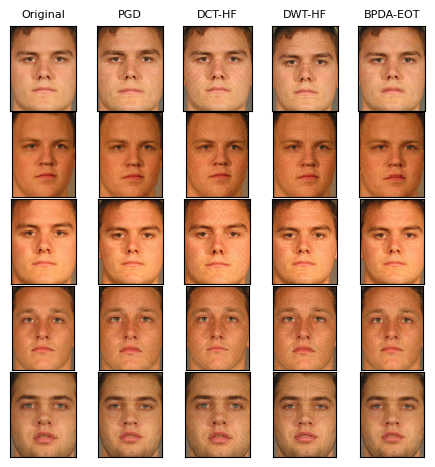

In [6]:
# Visualise

import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

NUM_SAMPLES = 5
dataset = "FRGC"
split = "train"

PERTURBATIONS = [
    "original",
    "Weighted_Ensemble_Template_PGD",
    "Weighted_Ensemble_Template_DCT_HF",
    "Weighted_Ensemble_Template_DWT_HF",
    "Weighted_Ensemble_Template_BPDA_EOT"
]

DISPLAY_NAMES = {
    "original": "Original",
    "Weighted_Ensemble_Template_PGD": "PGD",
    "Weighted_Ensemble_Template_DCT_HF": "DCT-HF",
    "Weighted_Ensemble_Template_DWT_HF": "DWT-HF",
    "Weighted_Ensemble_Template_BPDA_EOT": "BPDA-EOT"
}

base_original = OUTPUT_ROOT / dataset / "original" / "aligned" / split

sample_files = sorted(list(base_original.glob("*.png")))
sample_files = random.sample(sample_files, min(NUM_SAMPLES, len(sample_files)))

IMG_SIZE = 112

fig, axes = plt.subplots(
    len(sample_files),
    len(PERTURBATIONS),
    figsize=(len(PERTURBATIONS) * IMG_SIZE / 100, len(sample_files) * IMG_SIZE / 100),
    dpi=100
)

if len(sample_files) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, original_file in enumerate(sample_files):
    filename = original_file.name

    for col_idx, perturbation in enumerate(PERTURBATIONS):
        img_path = OUTPUT_ROOT / dataset / perturbation / "aligned" / split / filename
        ax = axes[row_idx][col_idx]

        if img_path.exists():
            img = np.array(Image.open(img_path))
            ax.imshow(img, interpolation="nearest")

        ax.set_xticks([])
        ax.set_yticks([])

        if row_idx == 0:
            ax.set_title(DISPLAY_NAMES[perturbation], fontsize=8)

plt.subplots_adjust(wspace=0.02, hspace=0.02)
plt.show()

## Generated Directory Structure
``` text
image-output/

├── FERET/
│   ├── original/
│   ├── Weighted_Ensemble_Template_PGD/
│   ├── Weighted_Ensemble_Template_DCT_HF/
│   ├── Weighted_Ensemble_Template_DWT_HF/
│   └── Weighted_Ensemble_Template_BPDA_EOT/
│
└── FRGC/
    ├── original/
    ├── Weighted_Ensemble_Template_PGD/
    ├── Weighted_Ensemble_Template_DCT_HF/
    ├── Weighted_Ensemble_Template_DWT_HF/
    └── Weighted_Ensemble_Template_BPDA_EOT/
```
Each perturbation folder contains:

- aligned/
- morph/
    - greedy/
    - mipgan2/
    - ubo/

with train/test splits preserved.